# Multisample 

Here we describe an intuitive adaptable approach to multi-sample integration for SpatialLeiden clustering in the 10x Visium spatial transcriptomics dataset of the human dorsolateral prefrontal cortex (DLPFC) ([Maynard et al., 2021](https://www.nature.com/articles/s41593-020-00787-0)). While we demonstrate the performance using [Harmony](https://github.com/slowkow/harmonypy), other users have had positive experiences using other tools such as [Novae](https://github.com/HiDiHlabs/SpatialLeiden/issues/22).


<div style="text-align: center;">
  <img src="../_static/images/multisample.png" alt="Multi-sample workflow" width="600">
</div>


This figure illustrates a workflow for spatialLeiden clustering with batch correction. Expression data of multiple samples undergo dimensionality reduction using PCA or scVI. The resulting embeddings get batch-corrected. Finally, a k-nearest neighbors (kNN) or BBKNN graph is constructed for downstream clustering analysis.


## Settings and Import

First of all we are going to load the relevant packages that we will be working with as well as setting a random seed that we will use throughout this example to make the results reproducible.

In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
from pathlib import Path

import anndata as ad
import scanpy as sc
import seaborn as sns
import squidpy as sq

seed = 42

/home/jovyan/spacehack-v3/projects/7_SpatialLeiden_multiX/SpatialLeiden2_Study/conda_envs/vignette/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Preproccess raw DLPFC data from spatialLIBD

Using `R` the DLPFC dataset is downloaded with `spatialLIBD`, and the data is saved as `.h5ad` with `zellkonverter`.

```R
# R Script to download DLPFC data and convert it to h5ad
library(spatialLIBD)
library(zellkonverter) 

spe <- fetch_data("spe")

coords <- as.data.frame(spatialCoords(spe))
colData(spe)$x <- coords$pxl_col_in_fullres
colData(spe)$y <- coords$pxl_row_in_fullres

writeH5AD(spe, file = file.path("./path/to/data", "raw.h5ad"))
```

## Load and preprocess

To optimize memory usage, large unused attributes like `obsm`, `uns`, and `layers` are removed. Spatial coordinates are extracted from the metadata and stored in `adata.obsm["spatial"]`. The gene and sample metadata are streamlined by selecting relevant columns, and the main expression matrix is converted to a sparse integer format.

In [3]:
libd_dlpfc_dir = Path("../data/LIBD_DLPFC")

adata = ad.read_h5ad(libd_dlpfc_dir / "raw.h5ad")

del adata.obsm, adata.uns, adata.layers

adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy().astype(int)
adata.var = adata.var[["gene_name", "gene_biotype"]]
adata.obs = adata.obs[["sample_id", "subject", "spatialLIBD"]]
adata.obs_names_make_unique()
adata.X = adata.X.tocsr().astype("int32")

/home/jovyan/spacehack-v3/projects/7_SpatialLeiden_multiX/SpatialLeiden2_Study/conda_envs/vignette/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


We subset the data for demonstration to only include cells from patient `Br8100`. 
A spatial neighborhood graph is generated with Squidpy using a regular grid (see {ref}`here <sec-spatialgraph>` for more information which spatial graph is suitable for your data).
Then, we perform standard preprocessing steps.
These include filtering genes, selecting spatially variable genes, normalization, log-transformation, scaling, and PCA for dimensionality reduction. The parameters and concrete steps can be adjusted according to your needs.

In [4]:
# Subset to 1 patient
adata = adata[adata.obs["subject"] == "Br8100"].copy()

# generate spatial graph
sq.gr.spatial_neighbors(adata, library_key="sample_id", coord_type="grid", n_neighs=6)

# gene filtering
sc.pp.filter_genes(adata, min_cells=10)

# scaling / normalization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.scale(adata)

# SVGs
sq.gr.spatial_autocorr(adata, genes=adata.var_names, mode="moran", seed=seed)
svgs = adata.uns["moranI"].nlargest(2_000, columns="I", keep="all").index
adata.var["svg"] = adata.var_names.isin(svgs)

sc.tl.pca(adata, n_comps=30, mask_var="svg", random_state=seed)

## Batch integration



First, Harmony is applied to correct batch effects between the samples of the patient. The batch-corrected PCA embeddings are stored in `adata.obsm["X_pca_harmony"]`. Next, a neighborhood graph is constructed based on these Harmony-corrected embeddings, considering the 15 nearest neighbors.Other batch correction methods like [scanorama](https://github.com/brianhie/scanorama), [bbknn](https://github.com/Teichlab/bbknn), and [scVI](https://github.com/scverse/scvi-tools) can also be used for this step, depending on the data and analysis preferences.

In [5]:
import harmonypy as hm

harmony_result = hm.run_harmony(
    adata.obsm["X_pca"], adata.obs, "sample_id", random_state=seed
)
adata.obsm["X_pca_harmony"] = harmony_result.Z_corr

sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca_harmony", random_state=seed)

2026-01-30 14:26:26,993 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-01-30 14:26:26,993 - harmonypy - INFO -   Parameters:
2026-01-30 14:26:26,994 - harmonypy - INFO -     max_iter_harmony: 10
2026-01-30 14:26:26,994 - harmonypy - INFO -     max_iter_kmeans: 20
2026-01-30 14:26:26,995 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-01-30 14:26:26,995 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-01-30 14:26:26,995 - harmonypy - INFO -     nclust: 100
2026-01-30 14:26:26,996 - harmonypy - INFO -     block_size: 0.05
2026-01-30 14:26:26,996 - harmonypy - INFO -     lamb: [1. 1. 1. 1.]
2026-01-30 14:26:26,997 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-01-30 14:26:26,997 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-01-30 14:26:26,998 - harmonypy - INFO -     verbose: True
2026-01-30 14:26:26,999 - harmonypy - INFO -     random_state: 42
2026-01-30 14:26:26,999 - harmonypy - INFO -   Data: 30 PCs × 14364 cells
2026-01-30 14:26:26,999 - har

## Clustering

SpatialLeiden combines the spatial information from the spatial graph with the neighborhood graph built from the batch-corrected expression data. To get the desired number of clusters, SpatialLeiden automatically searches over different resolutions and picks the one that comes closest to the target. ALternatively, if you don't know the number of clusters (which is usually the caseThe final cluster assignments are stored in `adata.obs`.

In [6]:
from spatialleiden import search_resolution

n_cluster = adata.obs["spatialLIBD"].nunique()

resolutions = search_resolution(
    adata,
    n_cluster,
    latent_kwargs={"directed": False, "random_state": seed},
    spatial_kwargs={"directed": False, "layer_ratio": 0.6, "random_state": seed},
)

## Visualizing SpatialLeiden multisample clusters across samples

After defining spatial domains with SpatialLeiden, we can check that these are actually spatially coherent across sections. Using joint clustering across multiple batch-corrected samples helps to identify consistent spatial patterns and improves the robustness of detected domains by leveraging shared biological signals.

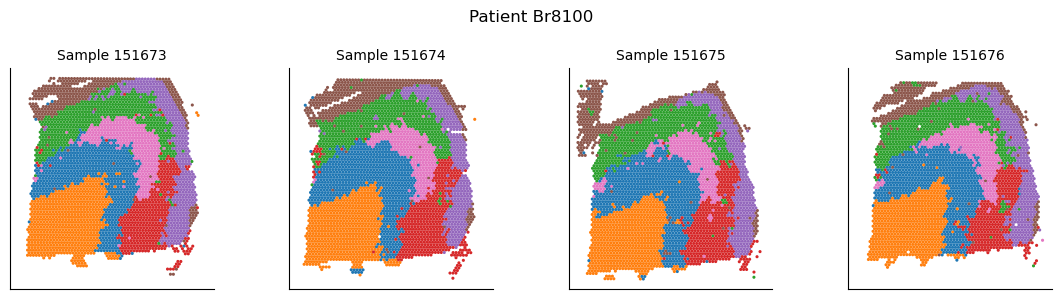

In [7]:
labels_integrated = adata.obs[["spatialleiden", "sample_id"]]
labels_integrated.loc[:, ["x", "y"]] = adata.obsm["spatial"]

g = sns.FacetGrid(labels_integrated, col="sample_id")

g.map_dataframe(
    sns.scatterplot, x="x", y="y", hue="spatialleiden", s=5, linewidth=0, legend=True
)

g.set_axis_labels("x", "y")
g.set_titles(col_template="Sample {col_name}")

ymin, ymax = g.axes.flat[0].get_ylim()

for ax in g.axes.flat:
    ax.set_ylim(ymax, ymin)  # flip y-axis
    ax.set_aspect("equal")
    ax.set(xticklabels=[], yticklabels=[], xlabel=None, ylabel=None)
    ax.tick_params(left=False, bottom=False)

g.fig.suptitle("Patient Br8100")
_ = g.tight_layout()